# AICE 모의고사 2회 - 온라인 쇼핑 판매량 예측

## 문제 시나리오

온라인 쇼핑몰의 제품 및 고객 데이터를 분석 및 전처리한 후 머신러닝과 딥러닝으로 특정 제품의 월별 판매량을 예측하고 결과를 분석하세요.

---

## 2-1 | 라이브러리 임포트 및 데이터 로딩

### 【 문제 】

- pandas를 pd로 임포트하는 코드를 작성하고 실행하세요.
- scikit-learn 패키지를 사전 임포트하는 코드를 작성하고 실행하세요.
- product_info.json을 읽어 데이터프레임 변수 df_product에 저장하세요.
- customer_demographics.csv를 읽어 데이터프레임 변수 df_customer에 저장하세요.


In [41]:
import pandas as pd
import sklearn as sk

df_product = pd.read_json('./product_info.json')
df_customer = pd.read_csv('./customer_demographics.csv')

## 2-2 | 데이터 병합 및 초기 탐색

### 【 문제 】

- ProductID를 기준 키(on)로 사용하여 inner 방식으로 두 데이터를 병합해 df를 생성하세요.
- 병합된 df의 기본 정보(컬럼, 데이터 타입, 결측치 등)를 확인하세요.
- df의 상위 5개 행을 출력해 구조를 빠르게 파악하세요.

In [42]:
# df_product.head()

df = pd.merge(df_product, df_customer, how='inner', on='ProductID')

df.head()

,ProductID,Category,Price,Rating,ReviewsCount,LaunchYear,PromotionApplied,AvgCustomerAge,AvgCustomerIncome,RegionPopularity,MonthlySales
0,1,Clothing,880,1.7,71,2022,Yes,46,57532,46,375.0
1,2,Electronics,7779,1.4,458,2022,No,23,35713,69,58.0
2,3,Electronics,230,1.1,769,2021,No,42,95545,56,352.0
3,4,Electronics,1284,2.2,21,2022,No,62,67892,33,335.0
4,5,Electronics,574,3.4,681,2021,No,18,130497,96,423.0


## 2-3 | 범주형 변수 로트 시각화 및 데이터 경제

### 【 문제 】

- matplotlib.pyplot을 plt, seaborn을 sns로 임포트하세요.
- Category 분포를 countplot으로 시각화하세요(정제 전).
- Category 중 'Misc'인 행을 삭제한 뒤, 삭제 전후 분포를 비교 시각화하세요.
- 삭제된 행의 개수를 답안03 변수에 저장하세요(예: 답안03 = 5).

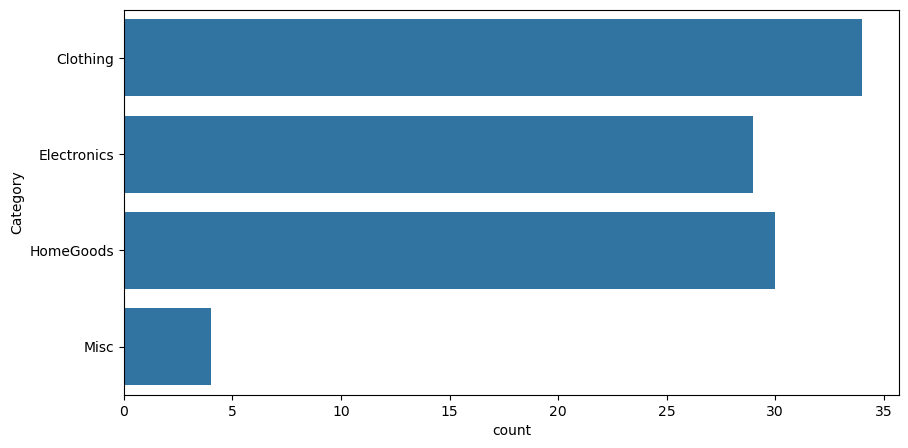

4


In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.countplot(data=df['Category'])
plt.show()

답안03 = df.shape[0] - df[df['Category'] != 'Misc'].copy().shape[0]
print(답안03)

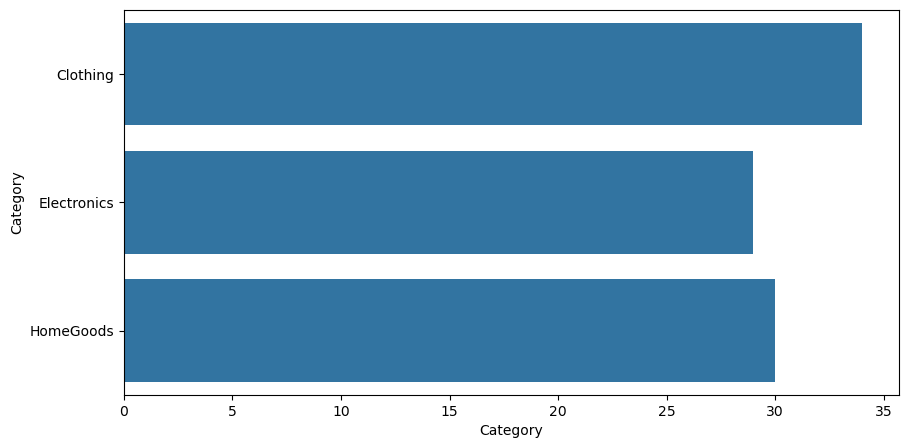

In [44]:
df = df[df['Category'] != 'Misc'].copy()

plt.figure(figsize=(10,5))
sns.countplot(data=df['Category'])
plt.xlabel('Category')
plt.show()

## 2-4 | 수치형 변수 관계 시각화 및 이상치 탐색

### 【 문제 】

- Price(x축)와 MonthlySales(y축)의 관계를 jointplot으로 시각화하세요.
- 그래프/데이터를 바탕으로 Price ≥ 5000을 이상치로 간주하고 개수를 답안04에 저장하세요.


8


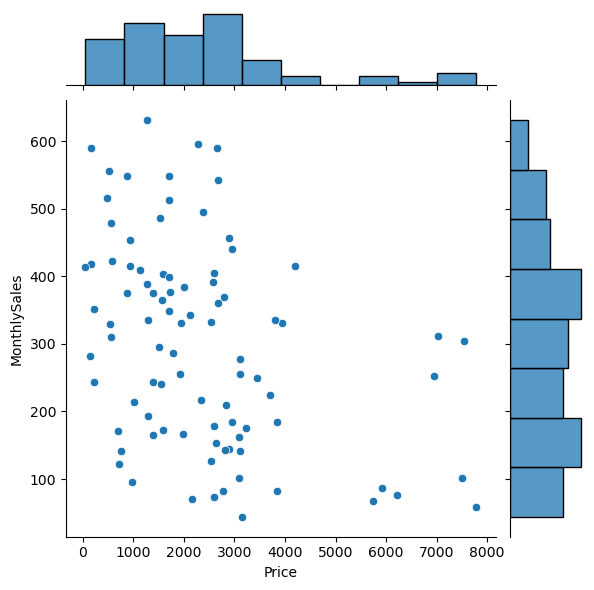

In [45]:
sns.jointplot(data=df, x='Price', y='MonthlySales')

답안04 = df[df['Price'] >= 5000].shape[0]
print(답안04)

## 2-5 | 이상치 및 불필요 컬럼 처리

### 【 문제 】

- Price ≥ 5000인 이상치 행을 삭제하세요.
- 예측에 직접 기여하지 않는 식별자 ProductID 컬럼을 삭제하세요.
- 결과를 df_temp에 저장하세요.

In [46]:
df_temp = df.copy()
df_temp = df_temp.drop('ProductID', axis=1)
df_temp.info()

df_temp = df_temp[df_temp['Price'] < 5000]

<class 'pandas.core.frame.DataFrame'>
Index: 93 entries, 0 to 96
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Category           93 non-null     object 
 1   Price              93 non-null     int64  
 2   Rating             93 non-null     float64
 3   ReviewsCount       93 non-null     int64  
 4   LaunchYear         93 non-null     int64  
 5   PromotionApplied   93 non-null     object 
 6   AvgCustomerAge     93 non-null     int64  
 7   AvgCustomerIncome  93 non-null     int64  
 8   RegionPopularity   93 non-null     int64  
 9   MonthlySales       90 non-null     float64
dtypes: float64(2), int64(6), object(2)
memory usage: 8.0+ KB


In [47]:
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, 0 to 96
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Category           85 non-null     object 
 1   Price              85 non-null     int64  
 2   Rating             85 non-null     float64
 3   ReviewsCount       85 non-null     int64  
 4   LaunchYear         85 non-null     int64  
 5   PromotionApplied   85 non-null     object 
 6   AvgCustomerAge     85 non-null     int64  
 7   AvgCustomerIncome  85 non-null     int64  
 8   RegionPopularity   85 non-null     int64  
 9   MonthlySales       82 non-null     float64
dtypes: float64(2), int64(6), object(2)
memory usage: 7.3+ KB


## 2-6 | 결측치 처리 및 데이터 타입 변환

### 【 문제 】

- df_temp의 결측치를 확인하세요.
- 결측치가 있는 행을 삭제한 뒤 결과를 df_na에 저장하세요.
- PromotionApplied를 Yes→1, No→0으로 변환하세요.
- 삭제된 결측치 행의 개수를 답안06에 저장하세요.

In [59]:
print(f'결측치 :\n{df_temp.isna().sum()}') 

# 전체 행 개수
initial_rows = df_temp.shape[0]
# 결측치 삭제 후의 df_na
df_na = df_temp.dropna().copy()
# 결측치 삭제 후의 행 개수
new_rows = df_na.shape[0]

답안06 = initial_rows - new_rows
print(f'답안06 : {답안06}')

df_na.info()

df_na['PromotionApplied'] = df_na['PromotionApplied'].map({'Yes':1, 'No':0})

df_na.info()

결측치 :
Category             0
Price                0
Rating               0
ReviewsCount         0
LaunchYear           0
PromotionApplied     0
AvgCustomerAge       0
AvgCustomerIncome    0
RegionPopularity     0
MonthlySales         3
dtype: int64
답안06 : 3
<class 'pandas.core.frame.DataFrame'>
Index: 82 entries, 0 to 96
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Category           82 non-null     object 
 1   Price              82 non-null     int64  
 2   Rating             82 non-null     float64
 3   ReviewsCount       82 non-null     int64  
 4   LaunchYear         82 non-null     int64  
 5   PromotionApplied   82 non-null     object 
 6   AvgCustomerAge     82 non-null     int64  
 7   AvgCustomerIncome  82 non-null     int64  
 8   RegionPopularity   82 non-null     int64  
 9   MonthlySales       82 non-null     float64
dtypes: float64(2), int64(6), object(2)
memory usage: 7.0+ KB
<class

## 2-7 | 불필요 컬럼 처리 및 범주형 변수 원-핫 인코딩

### 【 문제 】

- 본 문제에서는 Category와 MonthlySales만 남기고 나머지 컬럼은 삭제하세요(학습 단순화 목적).
- Category(object)를 원-핫 인코딩하여 수치형 변수로 변환하세요.
- 결과를 df_encoded에 저장하세요.


In [62]:
df_encoded = df_na[['Category', 'MonthlySales']].copy()
df_encoded = pd.get_dummies(data=df_encoded, columns=['Category'])

df_encoded.head()

,MonthlySales,Category_Clothing,Category_Electronics,Category_HomeGoods
0,375.0,True,False,False
2,352.0,False,True,False
3,335.0,False,True,False
4,423.0,False,True,False
5,145.0,True,False,False


## 2-8 | 데이터 분리 및 스케일링

### 【 문제 】

- X는 피처(MonthlySales 제외), y는 타깃(MonthlySales)으로 분리하세요.
- train_test_split으로 80:20 분할, random_state=42로 설정하세요.
- RobustScaler로 X_train, X_valid를 스케일링한 각각 X_train_scaled, X_valid_scaled로 저장하세요.


In [67]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

y = df_encoded['MonthlySales']
X = df_encoded.drop('MonthlySales', axis=1)

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

rs = RobustScaler()
X_train_scaled = rs.fit_transform(X_train)
X_valid_scaled = rs.fit_transform(X_valid)

## 2-9 | 머신러닝 모델 학습(RandomForestRegressor)

### 【 문제 】

- RandomForestRegressor를 생성하고, random_state=42로 설정하세요.
- X_train_scaled, y_train으로 모델을 학습시키고, 객체를 rf_model에 저장하세요.

In [69]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 2-10 | 머신러닝 모델 학습(GradientBoostingRegressor)

### 【 문제 】

- GradientBoostingRegressor를 random_state=42로 생성하세요.
- X_train_scaled, y_train으로 모델을 학습시키고, gb_model에 저장하세요.

In [70]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=42)

gb_model.fit(X_train_scaled, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


## 2-11 | 머신러닝 모델 성능 평가(MAE 비교)

### 【 문제 】

- rf_model, gb_model로 X_valid_scaled에 대한 예측을 수행하세요.
- mean_absolute_error(MAE)로 두 모델의 성능을 계산하세요. (예: 'RandomForest' 또는 'GradientBoosting')
- 더 낮은 MAE의 모델명을 문자열로 답안11에 저장하세요.


In [77]:
from sklearn.metrics import mean_absolute_error

rf_pred = rf_model.predict(X_valid_scaled)
gb_pred = gb_model.predict(X_valid_scaled)

rf_mae = mean_absolute_error(y_valid, rf_pred)
gb_mae = mean_absolute_error(y_valid, gb_pred)

print(rf_mae,'\n',gb_mae)
답안11 = 'GradientBoosting'

141.05556712889006 
 139.71313333563612


## 2-12 | 딥러닝 모델 개발 및 학습

### 【 문제 】

- tensorflow/keras를 임포트하고 tf.random.set_seed(1)로 재현성을 확보하세요.
- Dense 층을 사용하는 인공적인 다층 퍼셉트론(MLP/DNN) 회귀 모델을 Sequential로 구성하세요.
- 입력은 2D 텐서(샘플 수, 피처 수)를 그대로 사용합니다(reshape 3D 변환 불필요).
- 은닉 2개 이상에 ReLU 활성화 함수를 적용하고, Dropout(0.2)을 1개 이상 추가하세요.
- 출력은 Dense(1)로 구성하세요(회귀 문제).
- 옵티마이저 'adam', 손실함수 'mse', 평가지표 'mse'로 컴파일하세요.
- epochs=20, batch_size=16으로 학습하고, 검증 데이터는 (X_valid_scaled, y_valid)를 사용하세요.
- 학습 이력은 history_dl에 저장하세요.

In [87]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout

tf.random.set_seed(1)

dl_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

dl_model.compile(optimizer='adam', loss='mse', metrics=['mse'])

history_dl = dl_model.fit(X_train_scaled, y_train, epochs=20, batch_size=16, validation_data=(X_valid_scaled, y_valid))

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 130015.4453 - mse: 130015.4453 - val_loss: 78928.7812 - val_mse: 78928.7812
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 129934.0625 - mse: 129934.0625 - val_loss: 78853.3125 - val_mse: 78853.3125
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 129842.2188 - mse: 129842.2188 - val_loss: 78779.4688 - val_mse: 78779.4688
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 129740.1719 - mse: 129740.1719 - val_loss: 78705.2031 - val_mse: 78705.2031
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 129649.8438 - mse: 129649.8438 - val_loss: 78625.4688 - val_mse: 78625.4688
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 129555.8906 - mse: 129555.8906 - val_loss: 78535.3516 - val_mse: 78535.3516
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 129433.5859 - mse: 129433.5859 - val_loss: 78436.6875 - val_mse: 78436.6875
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 129295.3672 

## 2-13 | 딥러닝 학습 곡선 시각화

### 【 문제 】

- history_dl의 mse와 val_mse를 시각화하세요.
- Epochs에 따른 학습/검증 mse 추이를 같은 그래프에 표시하세요.


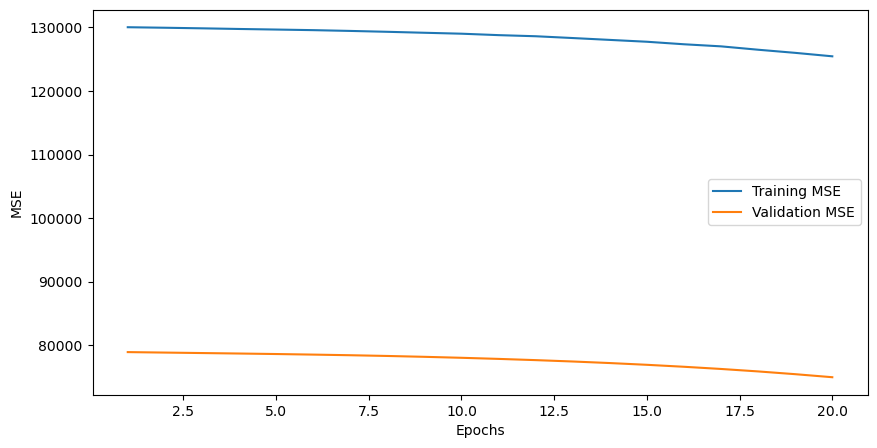

In [89]:
import matplotlib.pyplot as plt

train_mse = history_dl.history['mse']
val_mse = history_dl.history['val_mse']
epochs = range(1, len(train_mse)+1)

plt.figure(figsize=(10,5))
plt.plot(epochs, train_mse, label='Training MSE')
plt.plot(epochs, val_mse, label='Validation MSE')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.show()

## 2-14 | 최종 모델 선택 및 결론 도출

### 【 문제 】

- rf_model, gb_model, dl_model의 검증 성능을 MAE로 비교하세요.
- 가장 낮은 MAE를 보인 모델명을 답안14에 저장하세요 (예: 'RandomForest', 'GradientBoosting', 'DeepLearning (DNN)')
- 성능이 우수하더라도 학습시간/복잡도/해석 가능성 관점에서 실무 이들을 주석으로 작성하세요.

In [ ]:
y_pred_dl = dl_model.predict(X_valid_scaled)
dl_mae = mean_absolute_error(y_valid, y_pred_dl)

print(f'rf